# Eksplorativna analiza skupa podataka

U ovoj svesci upoznajemo skup podataka o NBA mečevima pre nego što na
njemu počnemo da gradimo atribute i modele.

Redosled odeljaka je sledeći: prvo utvrđujemo strukturu i osnovne mere skupa, zatim
pokazujemo zašto se statistika samog meča ne sme koristiti kao atribut
(najopasnija zamka ovog projekta), a onda tražimo signale koji **jesu**
legitimni — snagu tima, kretanje poena kroz vreme, prednost domaćeg
terena, plasman na tabeli i nedavnu formu. 

Svaki nalaz odavde direktno oblikuje odluke o atributima u pripremi podataka koja sledi.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [4]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from src.config import RANDOM_STATE, SEASON_SUSPENSION_DATE
from src import data, plotting

np.random.seed(RANDOM_STATE)

## Učitavanje podataka

In [5]:
df_games = data.load_games()
df_teams = data.load_teams()
df_rankings = data.load_rankings()

df_games.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2003-10-05,10300001,Final,1610612762,1610612742,2003,1610612762,90.0,0.457,0.735,...,23.0,41.0,1610612742,85.0,0.447,0.500,0.250,20.0,38.0,1
1,2003-10-06,10300002,Final,1610612763,1610612749,2003,1610612763,105.0,0.494,0.618,...,25.0,48.0,1610612749,94.0,0.427,0.700,0.154,20.0,43.0,1
2,2003-10-07,10300010,Final,1610612764,1610612752,2003,1610612764,104.0,0.506,0.677,...,26.0,45.0,1610612752,86.0,0.380,0.852,0.188,19.0,37.0,1
3,2003-10-07,10300009,Final,1610612758,1610612746,2003,1610612758,101.0,0.467,0.871,...,19.0,39.0,1610612746,82.0,0.368,0.609,0.364,13.0,50.0,1
4,2003-10-07,10300005,Final,1610612757,1610612745,2003,1610612757,104.0,0.527,0.657,...,22.0,33.0,1610612745,80.0,0.470,0.667,0.333,10.0,37.0,1


Sve tri tabele učitavamo preko `data.py`, jedne funkcije po tabeli, tako
da ostatak sveske ne mora da zna ništa o putanjama ili formatu CSV
datoteka. `df_teams` je pomoćna tabela imena i ovde je ne koristimo
dalje; `df_rankings` čekamo do odeljka o plasmanu. Prikaz prvih redova
`df_games` potvrđuje da su kolone učitane sa očekivanim imenima i da je
`GAME_DATE_EST` zaista parsiran kao datum, ne kao tekst.

## Struktura i nedostajuće vrednosti

In [6]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26651 entries, 0 to 26650
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   GAME_DATE_EST     26651 non-null  datetime64[ns]
 1   GAME_ID           26651 non-null  int64         
 2   GAME_STATUS_TEXT  26651 non-null  object        
 3   HOME_TEAM_ID      26651 non-null  int64         
 4   VISITOR_TEAM_ID   26651 non-null  int64         
 5   SEASON            26651 non-null  int64         
 6   TEAM_ID_home      26651 non-null  int64         
 7   PTS_home          26552 non-null  float64       
 8   FG_PCT_home       26552 non-null  float64       
 9   FT_PCT_home       26552 non-null  float64       
 10  FG3_PCT_home      26552 non-null  float64       
 11  AST_home          26552 non-null  float64       
 12  REB_home          26552 non-null  float64       
 13  TEAM_ID_away      26651 non-null  int64         
 14  PTS_away          2655

Dimenzije skupa podataka: 26651 red, 21 kolona. Tipovi su očekivani - datum, celobrojni ID-jevi,
procentualne i realne statistike — i `null` vrednosti se javljaju samo
u kolonama statistike meča (`PTS`, `FG_PCT`, ...), ne u identifikatorima
ili datumu. Pre nego što tu prazninu istražimo, korisno je znati šta
uopšte čini ovih 26651 reda: `GAME_ID` prvom cifrom kodira tip meča, pa
tu podelu pogledamo direktno.

In [7]:
data.game_type(df_games).value_counts()

GAME_ID
2    23273
1     1774
4     1591
5       13
Name: count, dtype: int64

U skupu se nalaze četiri vrste mečeva: **23273** regularne utakmice (kod `2`),
**1774** pripremne (kod `1`), **1591** plej-of (kod `4`) i samo **13**
plej-in (kod `5`) — plej-in format je uveden tek u poslednjim sezonama
skupa, pa je i očekivano da ga ima najmanje. Pripremne utakmice se igraju
rezervnim sastavima i ne opisuju realnu snagu tima, pa `clean_games` njih izbacuje u prvom koraku čišćenja. Ova podela je i dobra
osnova za proveru odakle dolaze nedostajuće vrednosti iz prethodne
ćelije.

In [8]:
df_games.isnull().sum()

GAME_DATE_EST        0
GAME_ID              0
GAME_STATUS_TEXT     0
HOME_TEAM_ID         0
VISITOR_TEAM_ID      0
SEASON               0
TEAM_ID_home         0
PTS_home            99
FG_PCT_home         99
FT_PCT_home         99
FG3_PCT_home        99
AST_home            99
REB_home            99
TEAM_ID_away         0
PTS_away            99
FG_PCT_away         99
FT_PCT_away         99
FG3_PCT_away        99
AST_away            99
REB_away            99
HOME_TEAM_WINS       0
dtype: int64

Statistika meča nedostaje u tačno 99 redova, i to uvek za domaćina i
gosta zajedno — znak da je ceo zapis meča nepotpun, ne greška u
pojedinačnoj koloni. Sledeća ćelija proverava da li ovih 99 redova ima
neko zajedničko obeležje, oslanjajući se na podelu po tipu meča iz
prethodnog koraka.

In [9]:
null_mask = df_games[data.GAME_STAT_COLUMNS].isnull().any(axis=1)
print(data.game_type(df_games)[null_mask].value_counts())
print(df_games.loc[null_mask, "SEASON"].value_counts())

GAME_ID
1    99
Name: count, dtype: int64
SEASON
2003    99
Name: count, dtype: int64


Podudaranje je potpuno: svih 99 nepotpunih redova su pripremne utakmice
(tip `1`) iz sezone 2003, najranije faze prikupljanja podataka. To znači
da filter tipa meča iz `clean_games` ne samo da uklanja nerelevantne
mečeve — on takodje rešava i problem nedostajućih vrednosti, jer je
ceo uzrok nedostajanja obuhvaćen istim filterom.

In [10]:
df_games["GAME_ID"].duplicated().sum()

29

29 mečeva ima ponovljen `GAME_ID`. Ovo je druga, nezavisna vrsta
problema od prethodne — ne nedostajanje, nego dupliranje — pa proveru
ponavljamo na isti način kao malopre, da vidimo da li i ona ima
prepoznatljiv uzrok.

In [11]:
dup_mask = df_games["GAME_ID"].duplicated(keep=False)
print(data.game_type(df_games)[dup_mask].value_counts())
print(df_games.loc[dup_mask, "SEASON"].value_counts())

GAME_ID
2    58
Name: count, dtype: int64
SEASON
2020    58
Name: count, dtype: int64


Ovog puta uzrok je drugačiji: svi duplikati su regularne utakmice iz
sezone 2020, verovatno nastali usled spajanja izvora podataka posle prekida
sezone zbog pandemije. Vrednosti statistike se u parovima razlikuju
samo u ispisu decimale (`0.343` naspram `0.3429999999999999`), pa
uklanjanje po celom redu ne bi radilo — zato se uklanjaju po `GAME_ID`,
uz zadržavanje prvog zapisa.

Sad kad znamo poreklo oba problema, možemo pozvati `clean_games()`
(`src/data.py`), koja ih rešava u okviru četiri koraka: izbacuje
pripremne utakmice, uklanja duplikate po `GAME_ID`, izbacuje mečeve bez
upisane statistike (što se, kako smo videli, poklapa sa prvim korakom)
i uklanja tri kolone bez informacije (`GAME_STATUS_TEXT`,
`TEAM_ID_home`, `TEAM_ID_away` — konstanta, odnosno tačne kopije
`HOME_TEAM_ID`/`VISITOR_TEAM_ID`).

In [12]:
df_games = data.clean_games(df_games)
df_games.shape

(24848, 18)

Od 26651 sirovih redova ostaje **24848**: 1774 pripremne utakmice i 29
duplikata su uklonjeni, dok korak koji izbacuje nepotpunu statistiku ne
uklanja ništa dodatno (ta 99 reda su, kako smo pokazali, već deo
uklonjenih pripremnih utakmica). Ovaj očišćen skup od 24848 mečeva
koristimo u ostatku sveske i on je polazna tačka za pripremu atributa.

## Zašto se statistika meča ne može koristiti direktno

Pre nego što krenemo da tražimo koristan signal u podacima, vredi jasno
pokazati šta se **ne sme** koristiti — to je najstroža greška koja može da se napravi. `games.csv` sadrži kolone poput `PTS_home` ili
`FG_PCT_home` koje opisuju sam odigrani meč, a ne stanje pre njega.
Ciljna promenljiva `HOME_TEAM_WINS` je doslovno izvedena iz razlike u
poenima, pa je očekivano da će ove kolone biti jako povezane sa njom —
pitanje je samo koliko jako.

In [13]:
# FG_PCT_home, PTS_home i slicne kolone su rezultat odigranog meca g
# i ne smeju uci kao atribut za taj isti mec (Pravilo 1)
game_stat_columns = ["PTS_home", "FG_PCT_home", "FT_PCT_home", "FG3_PCT_home", "AST_home", "REB_home"]
correlation_with_win = df_games[game_stat_columns + ["HOME_TEAM_WINS"]].corr()["HOME_TEAM_WINS"].drop("HOME_TEAM_WINS")
correlation_with_win.sort_values(ascending=False)

FG_PCT_home     0.433826
PTS_home        0.397040
AST_home        0.303415
FG3_PCT_home    0.300777
REB_home        0.247742
FT_PCT_home     0.093326
Name: HOME_TEAM_WINS, dtype: float64

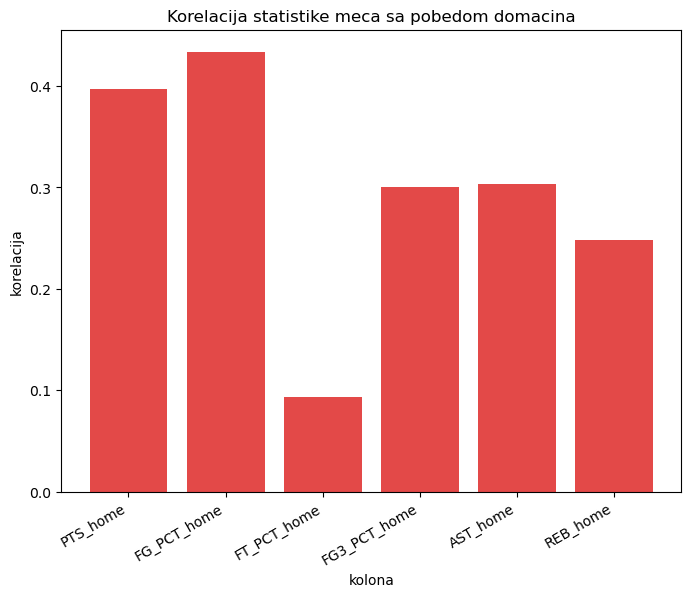

In [14]:
plotting.new_figure("Korelacija statistike meca sa pobedom domacina", "kolona", "korelacija")
plt.bar(correlation_with_win.index, correlation_with_win.values, color=plotting.COLOR_WARNING)
plt.xticks(rotation=30, ha="right")
plt.show()

Korelacija se kreće od zanemarljive do umerene: `FG_PCT_home` sa
**0.43** gotovo direktno definiše ko je pobedio — logično, jer procenat
pogodaka iz igre skoro pa jeste ishod meča. Na drugom kraju, `FT_PCT_home`
je sa **0.09** slaba, gotovo zanemarljiva veza — slobodna bacanja manje
zavise od toka meča. Ta razlika je poučna: opasnost ovih kolona nije u
tome *koliko jako* koreliraju, nego *kada* postaju poznate. `FT_PCT_home`
bi bila bezopasan atribut da je merena pre meča; pošto je merena tokom
njega, ne sme u model, bez obzira na to što je njena korelacija sama po
sebi slaba. Grafik je namerno crven, kao upozorenje: nijedna od ovih
kolona ne sme direktno u `features.py`. Sme samo njihova
`.shift(1).rolling(...)` verzija — prosek iz *prethodnih* mečeva, ne iz
tekućeg. U odeljcima koji slede tražimo baš takve, uzročne signale.

## Snaga timova

Prvi legitiman signal je najočigledniji: neki timovi su prosto bolji od
drugih. Da bismo ga izmerili nezavisno od toga da li je tim igrao kao
domaćin ili gost, svaki meč pretvaramo u dva reda umesto jednog — po
jedan za svaki učesnik.

In [15]:
# svaki mec postaje dva reda, po jedan za svaki tim, da bi se snaga tima
# mogla porediti nezavisno od toga da li je igrao kao domacin ili gost
df_home = df_games[["GAME_DATE_EST", "GAME_ID", "SEASON", "HOME_TEAM_ID", "HOME_TEAM_WINS"]].rename(
    columns={"HOME_TEAM_ID": "TEAM_ID", "HOME_TEAM_WINS": "WIN"}
)
df_away = df_games[["GAME_DATE_EST", "GAME_ID", "SEASON", "VISITOR_TEAM_ID", "HOME_TEAM_WINS"]].rename(
    columns={"VISITOR_TEAM_ID": "TEAM_ID"}
)
df_away["WIN"] = 1 - df_away["HOME_TEAM_WINS"]
df_away = df_away.drop(columns="HOME_TEAM_WINS")

df_team_view = pd.concat([df_home, df_away]).sort_values(["TEAM_ID", "GAME_DATE_EST"]).reset_index(drop=True)
df_team_view.shape

(49696, 5)

Ovaj „pogled po timu" (`df_team_view`) je ovde samo ilustrativan —
konačna, punija verzija (sa dodatnim kolonama i pokretnim statistikama)
ide u `features.py`. Broj redova je tačno dvostruko veći od broja
mečeva, jer je svaki meč sada predstavljen sa obe strane. Pitanje koje
nas zanima je koliko se timovi razlikuju po uspešnosti kad se
domaćin/gost efekat izdvoji — to meri procenat pobeda po timu i sezoni.

In [16]:
win_rate_by_team_season = df_team_view.groupby(["TEAM_ID", "SEASON"])["WIN"].mean()
win_rate_by_team_season.describe()

count    599.000000
mean       0.491240
std        0.142454
min        0.106061
25%        0.390244
50%        0.500000
75%        0.595949
max        0.838384
Name: WIN, dtype: float64

Na 599 kombinacija tim-sezona (30 timova kroz do 20 sezona; nešto manje
od 30×20 jer Charlotte (Hornets/Bobcats) u sezoni 2003 nije imao tim
u ligi — Hornets su te godine otišli u New Orleans, a Bobcats još nisu
počeli da igraju) prosek je **49.1%** —
očekivano blizu 50%, jer smo efekat domaćeg terena upravo izdvojili — sa
standardnom devijacijom od **14.2** procentna poena i rasponom od
**10.6%** do **83.8%**. Taj raspon je ono što nas zanima: razlika
između najslabije i najjače sezone jednog tima je ogromna, veća nego
razlika koju sam po sebi objašnjava domaći teren. Da bi ti brojevi
dobili smisao, vredi videti koji su timovi zapravo na krajevima te
raspodele.

In [17]:
# spajamo sa imenima timova da konkretizujemo raspon iz prethodne celije
win_rate_named = (
    win_rate_by_team_season.reset_index()
    .merge(df_teams[["TEAM_ID", "CITY", "NICKNAME"]], on="TEAM_ID")
    .sort_values("WIN")
)
pd.concat([win_rate_named.head(3), win_rate_named.tail(3)])

,TEAM_ID,SEASON,WIN,CITY,NICKNAME
587,1610612766,2011,0.106061,Charlotte,Hornets
372,1610612755,2015,0.121951,Philadelphia,76ers
286,1610612751,2009,0.146341,Brooklyn,Nets
151,1610612744,2014,0.805825,Golden State,Warriors
152,1610612744,2015,0.830189,Golden State,Warriors
153,1610612744,2016,0.838384,Golden State,Warriors


Najslabija sezona u skupu je **Charlotte 2011/12** sa samo **10.6%**
pobeda, odnosno 7 pobeda u 66 mečeva — istorijski poznat slučaj. (Tabela
prikazuje nadimak *Hornets*, jer `teams.csv` čuva današnje ime; te
sezone se tim zvao Bobcats.) Sezona je zbog lokauta skraćena na 66
mečeva, a kraća sezona znači manje prilike da se loš početak izravna, pa
su ekstremi statistički verovatniji. Na suprotnom kraju su tri uzastopne
sezone **Golden State Warriors** (2014–2016, do **83.8%** u 2016/17) —
dinastija izgrađena oko Curryja, Thompsona i, od 2016, Duranta. Isti
skup podataka, dakle, sadrži i tim u dubokom rebuild-u i tim na vrhuncu
dinastije — raspon koji nijedan prosečan pokazatelj domaćeg terena ne
može da objasni.

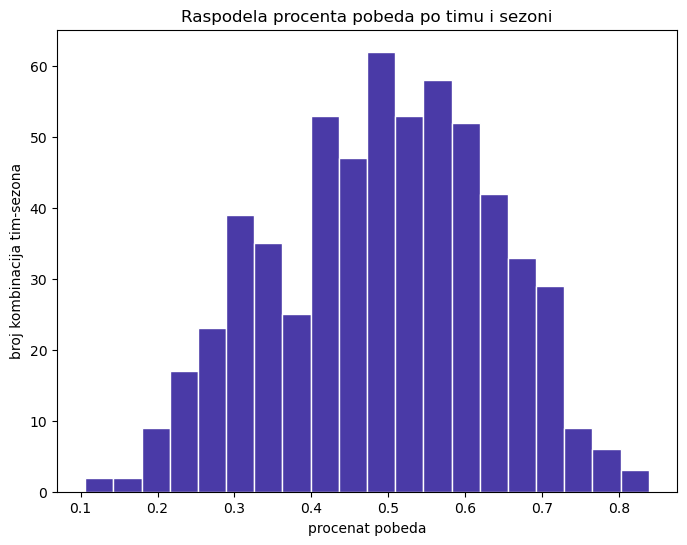

In [18]:
plotting.new_figure("Raspodela procenta pobeda po timu i sezoni", "procenat pobeda", "broj kombinacija tim-sezona")
plt.hist(win_rate_by_team_season, bins=20, color=plotting.COLOR_HIGHLIGHT, edgecolor="white")
plt.show()

Raspodela je približno zvonasta oko 50%, ali sa širokim repovima —
sezone poput Charlotte 2011/12 ili Warriors 2014–2016 nisu retki
izuzeci nego redovna pojava svake sezone (ispod 20% ili iznad 75%
pobeda). To je jasan argument da atributi na nivou tima moraju ući u
model. Vredi primetiti i da jedan broj po timu i sezoni ovde sve
izjednačava: tim koji je krenuo loše pa se popravio i tim koji je
propao u drugom delu sezone mogu imati isti procenat pobeda. To je prvi
nagoveštaj da bi pored agregata trebalo čuvati i redosled mečeva.

## Poeni kroz sezone

Sledeće pitanje je da li se sama igra promenila kroz skoro dve decenije
koje skup pokriva. Prosečni poeni po meču su gruba, ali brza mera tempa
igre.

In [19]:
points_by_season = df_games.groupby("SEASON")[["PTS_home", "PTS_away"]].mean()
points_by_season.tail()

,PTS_home,PTS_away
SEASON,,
2018,112.385671,109.592988
2019,112.671041,110.621172
2020,112.558497,111.382579
2021,111.265306,109.378685
2022,114.855346,111.519916


Poslednjih pet sezona (2018–2022) prosek se drži između 111 i 115 poena
po timu, primetno više nego što bismo očekivali na početku skupa. Da li
je to deo dužeg trenda ili samo skorašnja oscilacija, pokazuje grafik
kroz sve sezone, a tačan raspon dobijamo poređenjem prve i poslednje
sezone u skupu.

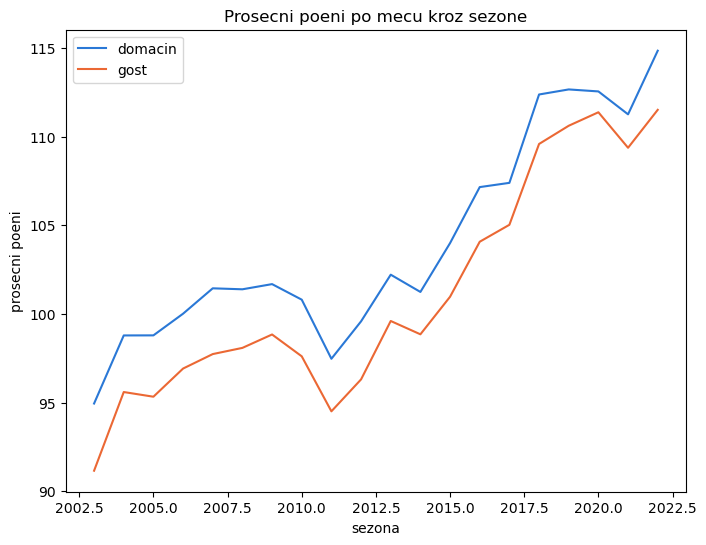

In [20]:
plotting.new_figure("Prosecni poeni po mecu kroz sezone", "sezona", "prosecni poeni")
plt.plot(points_by_season.index, points_by_season["PTS_home"], label="domacin", color=plotting.COLOR_HOME)
plt.plot(points_by_season.index, points_by_season["PTS_away"], label="gost", color=plotting.COLOR_AWAY)
plt.legend()
plt.show()

In [21]:
# prva i poslednja sezona u ocisecenom skupu, za tacno poredjenje rasta
points_by_season.iloc[[0, -1]]

,PTS_home,PTS_away
SEASON,,
2003,94.946499,91.154209
2022,114.855346,111.519916


Rast je gotovo monoton kroz ceo period: sa **94.9** poena kod domaćina
u sezoni 2003 na **114.9** u sezoni 2022 (kod gosta **91.2** → **111.5**)
— porast od oko 20 poena po meču, odnosno preko petine početne
vrednosti. Ovo je posledica ubrzanja tempa igre u NBA ligi poslednje
decenije (više šuteva za tri, brži napadi), ne promena u načinu merenja
statistike. Za ovaj projekat je poenta praktična: apsolutni broj poena
nosi vremenski trend koji nema veze sa snagom tima, pa su atributi
zasnovani na *razlici* ili *relativnom* učinku (kao pokretni prosek
pobeda) otporniji na ovaj trend od atributa u sirovim poenima.

Na oba kraja perioda domaćin ima viši prosek poena od gosta, a razlika
je stabilna kroz vreme — ne raste zajedno sa ukupnim tempom igre, što
je prvi nagoveštaj prednosti domaćeg terena kojom se bavi sledeći
odeljak.

## Prednost domaćeg terena

Prošli odeljak je nagovestio da domaćin u proseku postiže više poena.
Direktnija mera prednosti domaćeg terena je udeo pobeda domaćina po
sezoni.

In [22]:
home_wins_by_season = df_games.groupby("SEASON")["HOME_TEAM_WINS"].mean()
home_wins_by_season.tail()

SEASON
2018    0.590701
2019    0.546807
2020    0.546541
2021    0.547997
2022    0.610063
Name: HOME_TEAM_WINS, dtype: float64

Poslednjih pet sezona pokazuje pad pa delimičan oporavak — vrednosti se
kreću između 54.7% i 61.0%.
Ceo tok kroz svih 20 sezona, i to koliko je pad zapravo neuobičajen,
jasnije se vidi na grafiku.

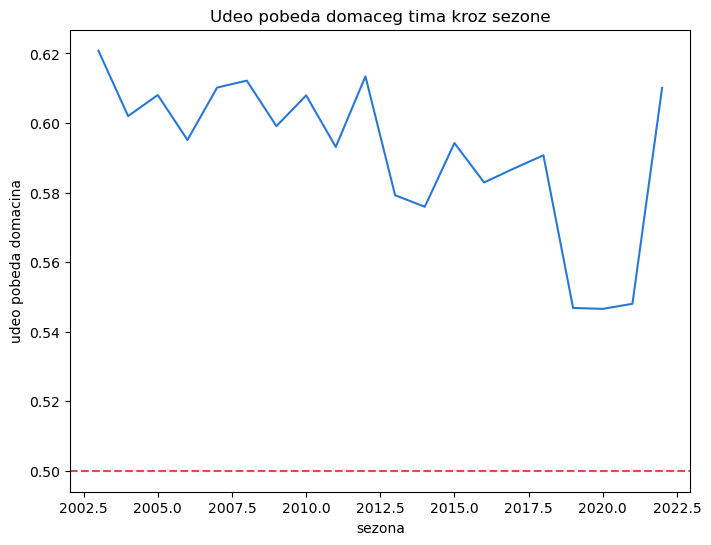

In [23]:
# SEASON_SUSPENSION_DATE (config.py) oznacava pocetak "bubble" faze sezone 2019/20,
# odigrane bez publike; taj deo sezone posebno proveravamo nize
plotting.new_figure("Udeo pobeda domaceg tima kroz sezone", "sezona", "udeo pobeda domacina")
plt.plot(home_wins_by_season.index, home_wins_by_season.values, color=plotting.COLOR_HOME)
plt.axhline(0.5, linestyle="--", color=plotting.COLOR_WARNING)
plt.show()

Kroz većinu istorije linija se drži u pojasu od otprilike **58%** do
**62%**, sa jasnim, izdvojenim udubljenjem u sezonama 2019–2021 — baš u
periodu pandemije COVID-19. To vremensko poklapanje je sugestivno, ali
samo po sebi ne dokazuje uzrok; sledeća ćelija proverava hipotezu o
publici direktno na podacima, ne na proseku po sezoni.

In [24]:
# provera da li je "bez publike" zaista tacan opis za sezonu 2019/20:
# deli se na deo pre i posle prekida (SEASON_SUSPENSION_DATE)
season_2019 = df_games[df_games["SEASON"] == 2019]
before_suspension = season_2019[season_2019["GAME_DATE_EST"] < SEASON_SUSPENSION_DATE]
after_suspension = season_2019[season_2019["GAME_DATE_EST"] >= SEASON_SUSPENSION_DATE]

print("pre prekida (puna publika):     ", len(before_suspension), "meceva, udeo pobeda domacina", round(before_suspension["HOME_TEAM_WINS"].mean(), 4))
print("posle prekida (bubble, bez publike):", len(after_suspension), "meceva, udeo pobeda domacina", round(after_suspension["HOME_TEAM_WINS"].mean(), 4))

pre prekida (puna publika):      967 meceva, udeo pobeda domacina 0.5512
posle prekida (bubble, bez publike): 176 meceva, udeo pobeda domacina 0.5227


Pretpostavka „bez publike" delimično stoji, ali samo za deo priče.
Bubble deo (posle 11.3.2020, zaista odigran bez publike, 176 mečeva) ima
nižu prednost domaćina (**52.3%**) nego deo iste sezone pre prekida (967
mečeva, **55.1%**), što ide u prilog hipotezi o publici. Ali čak i deo
sezone odigran uz punu publiku je već ispod istorijskog pojasa od
oko 58–62% — pad je, dakle, počeo *pre* bubble faze, pa se ne može
objasniti samo odsustvom navijača.

Sezone 2020 (2020/21, 54.7%) i 2021 (2021/22, 54.8%) nisu odigrane bez
publike: 2020/21 je imala smanjen kapacitet tribina u većini gradova (ne
nulu), a 2021/22 je uglavnom imala normalne uslove, uz kratkotrajna
ograničenja tokom Omikron talasa. Sezona 2022/23 pokazuje 61.0%, u
skladu sa istorijskim vrednostima, ali toj brojci ne treba pridavati
veliku težinu: skup se prekida u decembru 2022, pa ta sezona ima svega
477 mečeva umesto pune sezone od preko 1200, i pokriva samo prva dva
meseca. Ona nagoveštava da efekat nije trajan, ali to ne dokazuje.

Iz ovog skupa se ne može pouzdano utvrditi šta tačno uzrokuje pad u
sezonama 2020/21 i 2021/22 — posledice pandemije,
promene u sastavu timova i slučajna varijacija su podjednako mogući
faktori, a razdvojiti ih ne možemo. To ostaje otvoreno pitanje, ne
zaključak.

Za podelu skupa je važnija praktična posledica: sezona 2021/22 je
poslednja **kompletna** sezona u skupu, pa je test skup zasnovan na njoj
opravdan izbor, uz svest da i ona sama pokazuje sniženu prednost
domaćeg terena.

In [25]:
# razlika u poenima (domacin - gost), bez obzira ko je pobedio
point_difference = df_games["PTS_home"] - df_games["PTS_away"]

print("udeo pobeda domacina (ceo skup):", round(df_games["HOME_TEAM_WINS"].mean(), 4))
print("razlika u poenima - prosek:", round(point_difference.mean(), 2), " medijana:", point_difference.median())

udeo pobeda domacina (ceo skup): 0.591
razlika u poenima - prosek: 2.88  medijana: 4.0


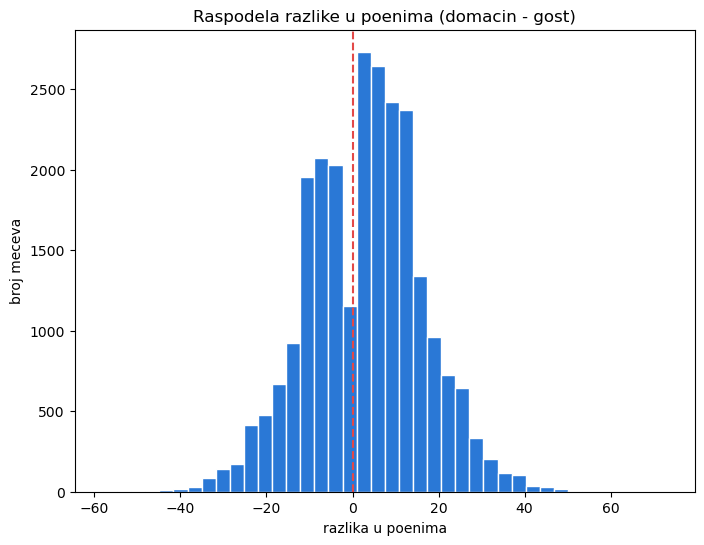

In [26]:
plotting.new_figure("Raspodela razlike u poenima (domacin - gost)", "razlika u poenima", "broj meceva")
plt.hist(point_difference, bins=40, color=plotting.COLOR_HOME, edgecolor="white")
plt.axvline(0, linestyle="--", color=plotting.COLOR_WARNING)
plt.show()

Kroz ceo očišćen skup domaćin pobeđuje u **59.1%** mečeva. To je i
balans klasa za ciljnu promenljivu: 59.1% naspram 40.9%, blaga
neuravnoteženost koja ne zahteva posebno tretiranje, ali je dovoljna da
trivijalni model „uvek pobeđuje domaćin" bude ozbiljna donja granica —
svaki model mora da je nadmaši da bismo razmatrali njegove pozitivne efekte.

Raspodela razlike u poenima je približno normalna, ali pomerena udesno:
prosek je **+2.88** poena u korist domaćina (medijana **+4**), a ne 0
kako bi se očekivalo bez prednosti domaćeg terena. To je ista prednost
domaćeg terena iz prethodnog grafika, samo izmerena na nivou
pojedinačnog meča umesto sezonskog proseka.

## Plasman timova iz ranking.csv

Do sada smo merili snagu tima kroz celu sezonu unazad (`win_rate_by_team_season`)
i prednost domaćeg terena kao prosek celog skupa. Ono što bi bio pravi
pred-mečevski atribut je nešto sredinom: plasman tima na tabeli *u
trenutku* kad se meč igra. `ranking.csv` daje procenat pobeda (`W_PCT`)
svakog tima na dan `STANDINGSDATE`, ažuriran kroz celu sezonu, pa to
možemo izmeriti direktno.

In [27]:
# SEASON_ID prvom cifrom kodira tip sezone, isto kao GAME_ID: "2" je regularna,
# "1" pripremna; plej-of nema odvojeni plasman pa koristi poslednji poznat
df_standings = df_rankings[df_rankings["SEASON_ID"].astype(str).str[0] == "2"].copy()
df_standings = df_standings.sort_values("STANDINGSDATE")
df_standings.shape

(197489, 13)

Da bismo ovaj plasman spojili sa svakim mečom, potreban je asof-spoj:
za svaki meč tražimo poslednji poznat `W_PCT` tima **strogo pre**
datuma meča, ne na dan meča ili posle njega — inače bi atribut mogao da
uključi rezultat meča koji tek treba da predvidimo.

In [28]:
def standings_before_game(team_column):
    """Spaja plasman tima sa poslednjim poznatim W_PCT strogo pre datuma meca.

    allow_exact_matches=False iskljucuje red plasmana od istog dana kao mec,
    jer taj red moze vec da ukljucuje rezultat tog istog meca.
    """
    df_left = (
        df_games[["GAME_DATE_EST", "GAME_ID", team_column]]
        .sort_values("GAME_DATE_EST")
        .rename(columns={team_column: "TEAM_ID"})
    )
    df_merged = pd.merge_asof(
        df_left,
        df_standings[["TEAM_ID", "STANDINGSDATE", "W_PCT"]],
        left_on="GAME_DATE_EST", right_on="STANDINGSDATE",
        by="TEAM_ID", direction="backward", allow_exact_matches=False,
    )
    return df_merged.set_index("GAME_ID")["W_PCT"]


wpct_home_before = standings_before_game("HOME_TEAM_ID")
wpct_away_before = standings_before_game("VISITOR_TEAM_ID")

df_standings_gap = df_games.set_index("GAME_ID")[["SEASON", "HOME_TEAM_WINS"]].copy()
df_standings_gap["WPCT_GAP"] = wpct_home_before - wpct_away_before
df_standings_gap = df_standings_gap.dropna(subset=["WPCT_GAP"])

print("pokriveni mecevi:", len(df_standings_gap), "od", len(df_games))
df_standings_gap["WPCT_GAP"].corr(df_standings_gap["HOME_TEAM_WINS"])

pokriveni mecevi: 24848 od 24848


0.29727754900305586

`ranking.csv` pokriva svih **24848** mečeva iz očišćenog skupa — svaki
meč ima poznat plasman oba tima strogo pre svog datuma (za plej-of
mečeve to je poslednji plasman iz redovnog dela sezone, jer se tabela
posle njenog završetka više ne ažurira). Korelacija razlike u procentu
pobeda (`WPCT_GAP`) sa ishodom je **0.297** — vidno jača od bilo koje
mere koju smo do sada gradili iz same tabele `games.csv`, jer plasman
sažima celu dotadašnju sezonu, ne samo par prethodnih mečeva. Da bismo
videli i oblik te veze, ne samo njenu jačinu, grupišemo mečeve po
veličini razlike u plasmanu.

In [29]:
gap_bins = [-1.01, -0.3, -0.1, 0.1, 0.3, 1.01]
gap_labels = ["domacin mnogo losiji", "domacin losiji", "priblizno isti", "domacin bolji", "domacin mnogo bolji"]
df_standings_gap["GAP_GROUP"] = pd.cut(df_standings_gap["WPCT_GAP"], bins=gap_bins, labels=gap_labels)

gap_vs_win = df_standings_gap.groupby("GAP_GROUP", observed=True)["HOME_TEAM_WINS"].agg(["mean", "count"])
gap_vs_win

,mean,count
GAP_GROUP,,
domacin mnogo losiji,0.335401,2740
domacin losiji,0.439438,5482
priblizno isti,0.600722,8583
domacin bolji,0.745576,5369
domacin mnogo bolji,0.821990,2674


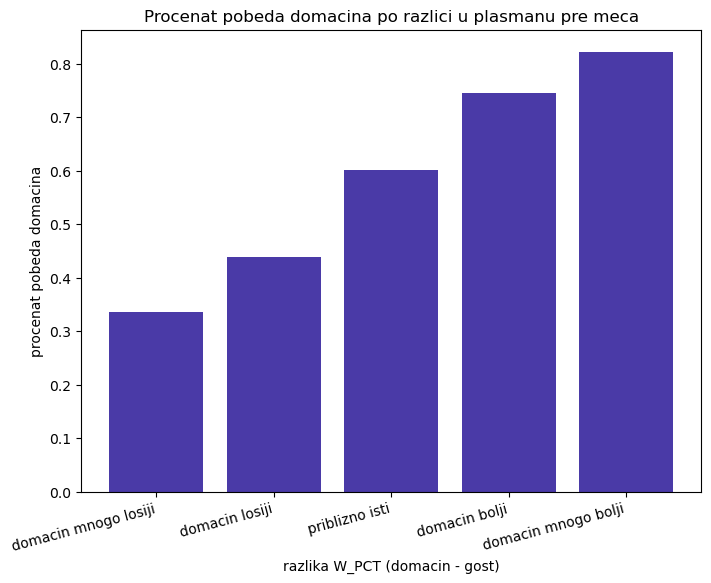

In [30]:
plotting.new_figure("Procenat pobeda domacina po razlici u plasmanu pre meca", "razlika W_PCT (domacin - gost)", "procenat pobeda domacina")
plt.bar(gap_vs_win.index.astype(str), gap_vs_win["mean"], color=plotting.COLOR_HIGHLIGHT)
plt.xticks(rotation=15, ha="right")
plt.show()

Veza je jasno monotona i strma: kada je domaćin mnogo lošiji od gosta na
tabeli, pobeđuje u samo **33.5%** mečeva; kada je mnogo bolji, u **82.2%**.
To je najjači pojedinačni signal pronađen u ovoj svesci, i jasan argument
da atributi iz `ranking.csv` uđu u `features.py` uz pokretne statistike
iz `games.csv`, ne umesto njih.

## Forma tima kroz prethodne mečeve

Plasman na tabeli sažima celu sezonu, ali sezona traje mesecima, a
timovi variraju i u kraćim periodima — povrede, raspored, motivacija.
Poslednji signal koji proveravamo je forma: procenat pobeda tima u
poslednjih nekoliko mečeva, neposredno pre tekućeg.

In [31]:
# shift(1) obezbedjuje da forma pre meca g koristi samo meceve odigrane pre njega
df_team_view["WIN_RATE_LAST5"] = (
    df_team_view.groupby("TEAM_ID")["WIN"]
    .transform(lambda s: s.shift(1).rolling(5).mean())
)
df_form = df_team_view.dropna(subset=["WIN_RATE_LAST5"]).copy()

form_bins = [-0.01, 0.2, 0.4, 0.6, 0.8, 1.01]
form_labels = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
df_form["FORM_GROUP"] = pd.cut(df_form["WIN_RATE_LAST5"], bins=form_bins, labels=form_labels)

form_vs_win = df_form.groupby("FORM_GROUP", observed=True)["WIN"].agg(["mean", "count"])
form_vs_win

,mean,count
FORM_GROUP,,
0-20%,0.389154,11507
20-40%,0.471576,13105
40-60%,0.538519,13448
60-80%,0.586817,8708
80-100%,0.634269,2778


Procenat pobeda u tekućem meču raste skoro monotono sa formom iz
prethodnih 5 mečeva: od **38.9%** (tim je bio u lošoj formi) do **63.4%**
(tim je bio u odličnoj formi). Ovo je legitiman, uzročan signal —
`shift(1)` garantuje da se ne koristi ishod meča koji se predviđa. Da
bismo ovu vezu uporedili sa plasmanom iz prethodnog odeljka, merimo je
i istom korelacijom.

In [32]:
df_form["WIN_RATE_LAST5"].corr(df_form["WIN"])

0.15361828571973724

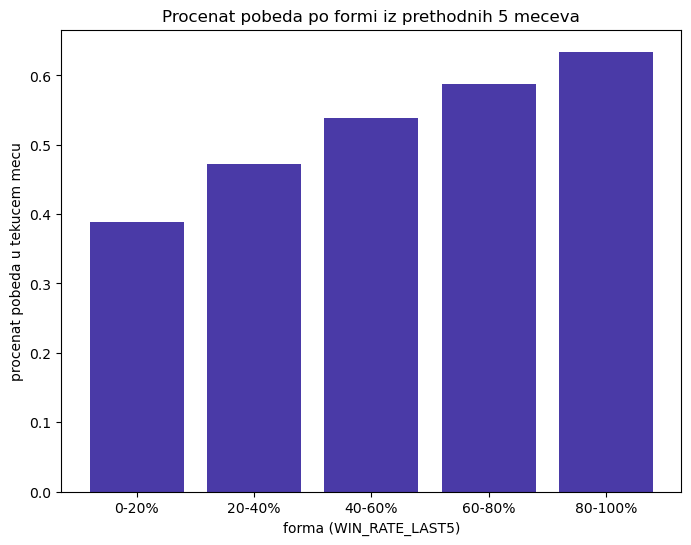

In [33]:
plotting.new_figure("Procenat pobeda po formi iz prethodnih 5 meceva", "forma (WIN_RATE_LAST5)", "procenat pobeda u tekucem mecu")
plt.bar(form_vs_win.index.astype(str), form_vs_win["mean"], color=plotting.COLOR_HIGHLIGHT)
plt.show()

Veza je jasno monotona, ali je korelacija forme sa pobedom (**0.154**)
osetno slabija od razlike u plasmanu (**0.297**, prethodni odeljak).
Razlog je što prozor od 5 mečeva sažima kraći vremenski period, dok
plasman sažima celu dotadašnju sezonu.

Zanimljivo je da je forma po korelaciji ipak jača od `FT_PCT_home`
(0.093) iz odeljka o curenju — a ta kolona je zabranjena, dok je forma
dozvoljena. To lepo pokazuje da jačina korelacije nije kriterijum za to
sme li nešto biti atribut; kriterijum je isključivo *kada* postaje
poznato.

Za nas je ovde bitna posledica: jedan agregat sažima svih pet mečeva u
jedan broj i gubi njihov redosled i kontekst. Zato pored agregatnih
atributa čuvamo i celu sekvencu prethodnih mečeva, da model može sam da
odluči koliko duboko u istoriju gleda i kojim mečevima daje veći
značaj.

## Zaključak

Ova sveska daje tri vrste nalaza koji oblikuju pripremu podataka: šta o
skupu treba znati pre bilo kakve obrade, šta se kategorički ne sme
koristiti kao atribut, i koji legitimni signali postoje i koliko je koji
jak.

**O samom skupu.** Posle čišćenja ostaje 24848 mečeva iz sezona
2003/04–2022/23, pri čemu je poslednja nepotpuna. Klase su blago
neuravnotežene u korist domaćina (59.1% / 40.9%), dovoljno da „uvek
pobeđuje domaćin" bude netrivijalna donja granica, ali ne toliko da
zahteva balansiranje skupa. Prosečni poeni po meču rastu skoro monotono
kroz istoriju skupa (94.9 → 114.9 kod domaćina), pa atributi zasnovani
na razlici ili relativnom učinku bolje podnose taj trend od atributa u
sirovim poenima.

**Šta se ne sme koristiti.** Statistika samog meča (`PTS_home`,
`FG_PCT_home` i slično) korelira sa ishodom sa 0.09 do čak 0.43, upravo
zato što je njegova **posledica**, ne uzrok. Nijedna od tih kolona ne
sme direktno u `features.py` — smeju samo njihove pomerene i pokretne
verzije.

**Šta jeste legitimno, po jačini signala:**

- **plasman na tabeli pre meča** (`ranking.csv`) — korelacija **0.297**,
  raspon pobeda 33.5%–82.2% po grupama razlike u plasmanu; najjači
  pojedinačni signal pronađen u ovoj svesci
- **prednost domaćeg terena** — po sezonama 57.6%–62.1% zaključno sa
  2018/19, pa pad na 54.7–54.8% u sezonama 2019–2021; deo tog pada je
  objašnjen odsustvom publike u bubble fazi, a ostatak ostaje otvoreno
  pitanje
- **forma iz prethodnih 5 mečeva** — korelacija **0.154**, slabija od
  plasmana jer sažima samo uzan vremenski prozor; jedan agregat pritom
  gubi redosled mečeva, što je argument da se sekvenca sačuva u celini
- **snaga tima po sezoni** — raspon 10.6%–83.8% pobeda po timu-sezoni,
  potvrđuje da je razlika između timova prevelika da bi se zanemarila,
  ali je to prespora mera (cela sezona) da bi sama bila dovoljna

Sledeći korak je priprema podataka: ova tri legitimna signala —
plasman, formu i pokretne statistike iz `games.csv` — treba objediniti u
tabelu atributa i u sekvence po meču, uz hronološku podelu na trening,
validaciju i test čije su granice utvrđene u `src/config.py`.